In [5]:
subprocess.run(["pip", "install", "seaborn"])

CompletedProcess(args=['pip', 'install', 'seaborn'], returncode=0)

In [6]:
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os
import warnings
warnings.filterwarnings('ignore')

load_dotenv()

engine = create_engine(os.getenv("DATABASE_URL"))

print("✅ Conexión exitosa a PostgreSQL")
print(f"📊 Base de datos: {engine.url.database}")

✅ Conexión exitosa a PostgreSQL
📊 Base de datos: system_admin


In [7]:
# Cargar tablas en DataFrames
df_purchases = pd.read_sql("SELECT * FROM purchases", engine)
df_companies = pd.read_sql("SELECT * FROM companies", engine)
df_products = pd.read_sql("SELECT * FROM products", engine)
df_customers = pd.read_sql("SELECT * FROM customers", engine)
df_prices = pd.read_sql("SELECT * FROM company_product_prices", engine)

print(f"✅ Compras:   {len(df_purchases)} registros")
print(f"✅ Empresas:  {len(df_companies)} registros")
print(f"✅ Productos: {len(df_products)} registros")
print(f"✅ Clientes:  {len(df_customers)} registros")
print(f"✅ Precios:   {len(df_prices)} registros")

✅ Compras:   504 registros
✅ Empresas:  22 registros
✅ Productos: 51 registros
✅ Clientes:  103 registros
✅ Precios:   1224 registros


In [8]:
print("═" * 50)
print("COMPRAS — estructura")
print("═" * 50)
print(df_purchases.dtypes)
print(f"\nValores nulos:\n{df_purchases.isnull().sum()}")
print(f"\nEstadísticas:\n{df_purchases[['unit_price', 'quantity', 'total']].describe().round(2)}")

══════════════════════════════════════════════════
COMPRAS — estructura
══════════════════════════════════════════════════
id                             int64
customer_id                    int64
company_product_id             int64
created_at            datetime64[us]
updated_at            datetime64[us]
unit_price                   float64
quantity                       int64
total                        float64
dtype: object

Valores nulos:
id                    0
customer_id           0
company_product_id    0
created_at            0
updated_at            0
unit_price            0
quantity              0
total                 0
dtype: int64

Estadísticas:
       unit_price  quantity    total
count      504.00    504.00   504.00
mean        29.35     10.01   287.71
std         17.34      5.90   262.69
min          1.09      1.00     1.38
25%         15.79      5.00    69.65
50%         29.51     10.00   218.94
75%         42.55     15.00   400.18
max         72.69     20.00  1453.8

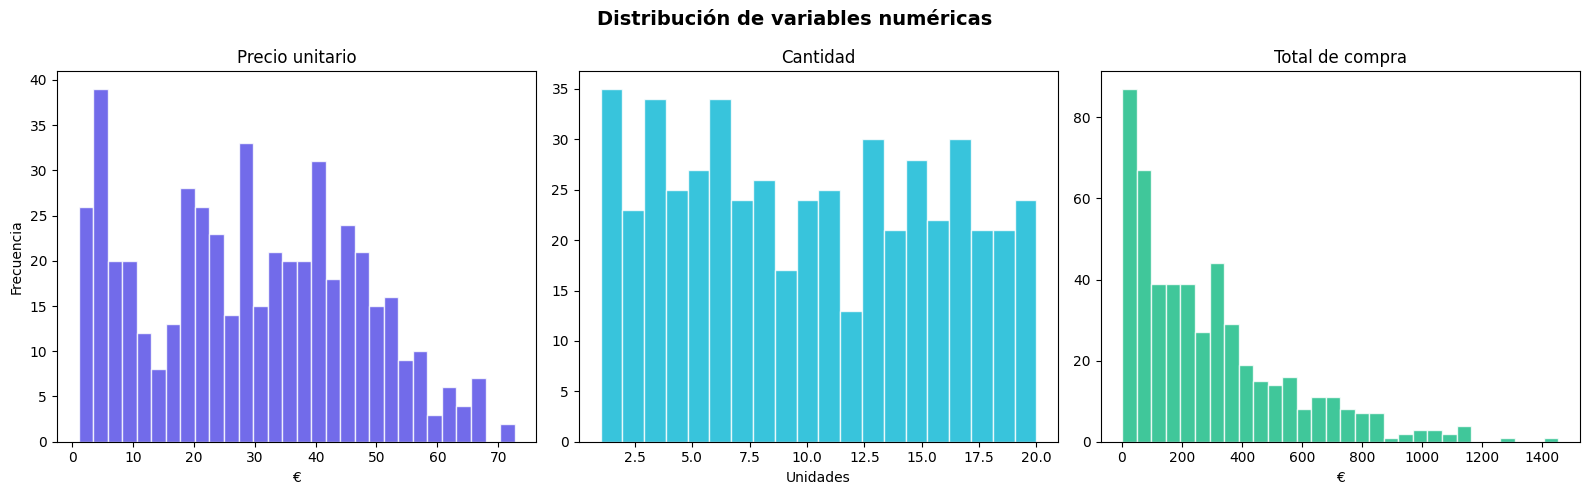

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Distribución de variables numéricas", fontsize=14, fontweight='bold')

# Unit price
axes[0].hist(df_purchases['unit_price'], bins=30, color='#4f46e5', edgecolor='white', alpha=0.8)
axes[0].set_title("Precio unitario")
axes[0].set_xlabel("€")
axes[0].set_ylabel("Frecuencia")

# Quantity
axes[1].hist(df_purchases['quantity'], bins=20, color='#06b6d4', edgecolor='white', alpha=0.8)
axes[1].set_title("Cantidad")
axes[1].set_xlabel("Unidades")

# Total
axes[2].hist(df_purchases['total'], bins=30, color='#10b981', edgecolor='white', alpha=0.8)
axes[2].set_title("Total de compra")
axes[2].set_xlabel("€")

plt.tight_layout()
plt.show()

In [10]:
# Ventas por empresa
df_merged = df_purchases.merge(
    pd.read_sql("""
        SELECT cp.id as company_product_id, c.name as company_name
        FROM company_product cp
        JOIN companies c ON c.id = cp.company_id
    """, engine),
    on='company_product_id'
)

ventas_empresa = df_merged.groupby('company_name').agg(
    total_ventas=('total', 'sum'),
    num_compras=('id', 'count'),
    ticket_medio=('total', 'mean')
).sort_values('total_ventas', ascending=False)

print(ventas_empresa.round(2))

                                    total_ventas  num_compras  ticket_medio
company_name                                                               
Talleres Pons S.Coop.                   13405.65           32        418.93
Familia Coloma S.A.                     10551.71           32        329.74
Sevilla & Asociados S.A.                10446.02           32        326.44
MER                                     10330.81           30        344.36
Atilio Gascón Velasco S.A.               9510.35           31        306.79
Castell & Asociados S.L.U.               8869.71           35        253.42
Ciriaco Gual Riquelme S.Coop.            8436.71           26        324.49
Despacho VK S.L.N.E                      8216.41           30        273.88
Esteve & Asociados S.Coop.               7721.43           30        257.38
Talleres Pagès y asociados S.Coop.       7230.36           33        219.10
Banca Privada del Noroeste S.L.N.E       6086.96           18        338.16
Teófila Coll

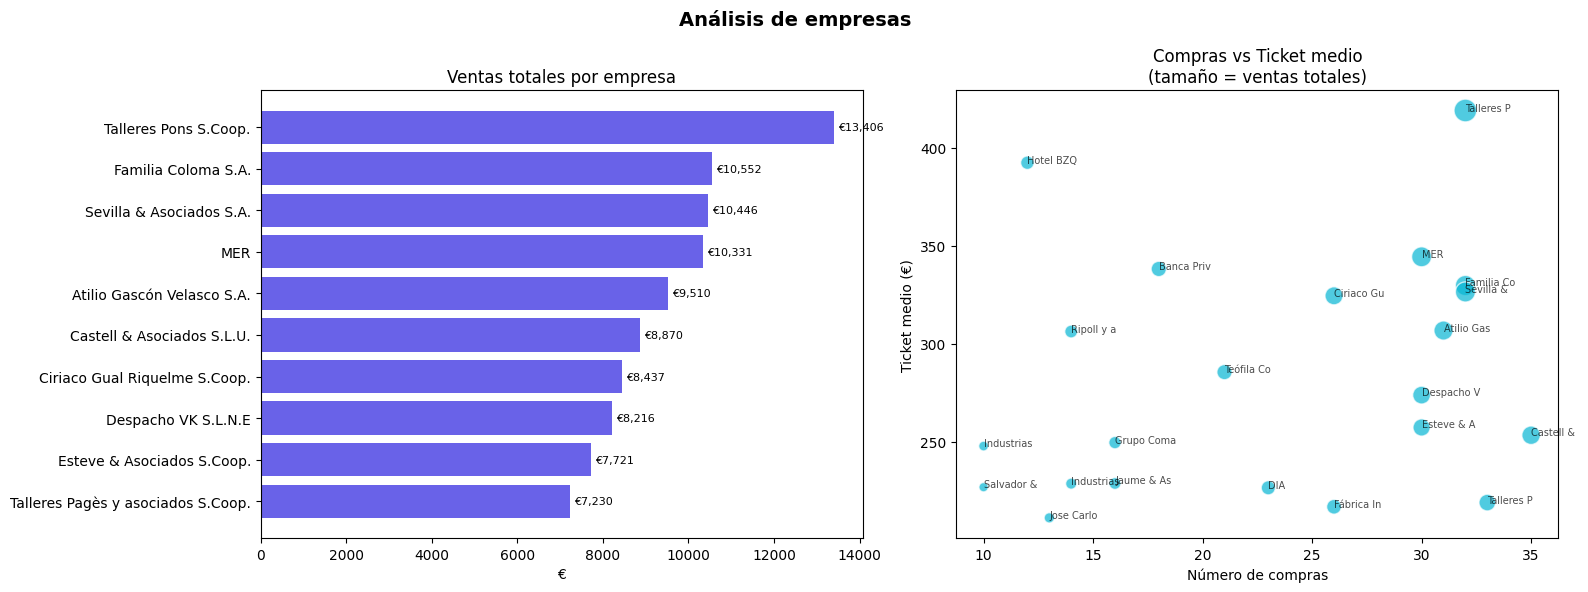

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Análisis de empresas", fontsize=14, fontweight='bold')

# Barras: ventas totales
top10 = ventas_empresa.head(10)
axes[0].barh(top10.index, top10['total_ventas'], color='#4f46e5', alpha=0.85)
axes[0].set_title("Ventas totales por empresa")
axes[0].set_xlabel("€")
axes[0].invert_yaxis()
for i, (val, name) in enumerate(zip(top10['total_ventas'], top10.index)):
    axes[0].text(val + 100, i, f"€{val:,.0f}", va='center', fontsize=8)

# Scatter: número de compras vs ticket medio
axes[1].scatter(
    ventas_empresa['num_compras'],
    ventas_empresa['ticket_medio'],
    s=ventas_empresa['total_ventas'] / 50,
    color='#06b6d4',
    alpha=0.7,
    edgecolors='white'
)
axes[1].set_title("Compras vs Ticket medio\n(tamaño = ventas totales)")
axes[1].set_xlabel("Número de compras")
axes[1].set_ylabel("Ticket medio (€)")

for idx, row in ventas_empresa.iterrows():
    axes[1].annotate(
        idx[:10],
        (row['num_compras'], row['ticket_medio']),
        fontsize=7,
        alpha=0.7
    )

plt.tight_layout()
plt.show()

In [12]:
# Comportamiento de clientes
cliente_stats = df_purchases.groupby('customer_id').agg(
    total_gastado=('total', 'sum'),
    num_compras=('id', 'count'),
    ticket_medio=('total', 'mean'),
    cantidad_total=('quantity', 'sum')
).reset_index()

print("═" * 50)
print("RESUMEN DE CLIENTES")
print("═" * 50)
print(f"Clientes con compras:     {len(cliente_stats)}")
print(f"Gasto promedio:           €{cliente_stats['total_gastado'].mean():,.2f}")
print(f"Gasto máximo:             €{cliente_stats['total_gastado'].max():,.2f}")
print(f"Compras promedio/cliente: {cliente_stats['num_compras'].mean():.1f}")
print(f"\nDistribución por gasto:")
print(pd.cut(cliente_stats['total_gastado'],
    bins=[0, 500, 1000, 2000, 5000],
    labels=['<€500', '€500-1k', '€1k-2k', '>€2k']
).value_counts().sort_index())

══════════════════════════════════════════════════
RESUMEN DE CLIENTES
══════════════════════════════════════════════════
Clientes con compras:     103
Gasto promedio:           €1,407.83
Gasto máximo:             €3,954.17
Compras promedio/cliente: 4.9

Distribución por gasto:
total_gastado
<€500      14
€500-1k    26
€1k-2k     42
>€2k       21
Name: count, dtype: int64


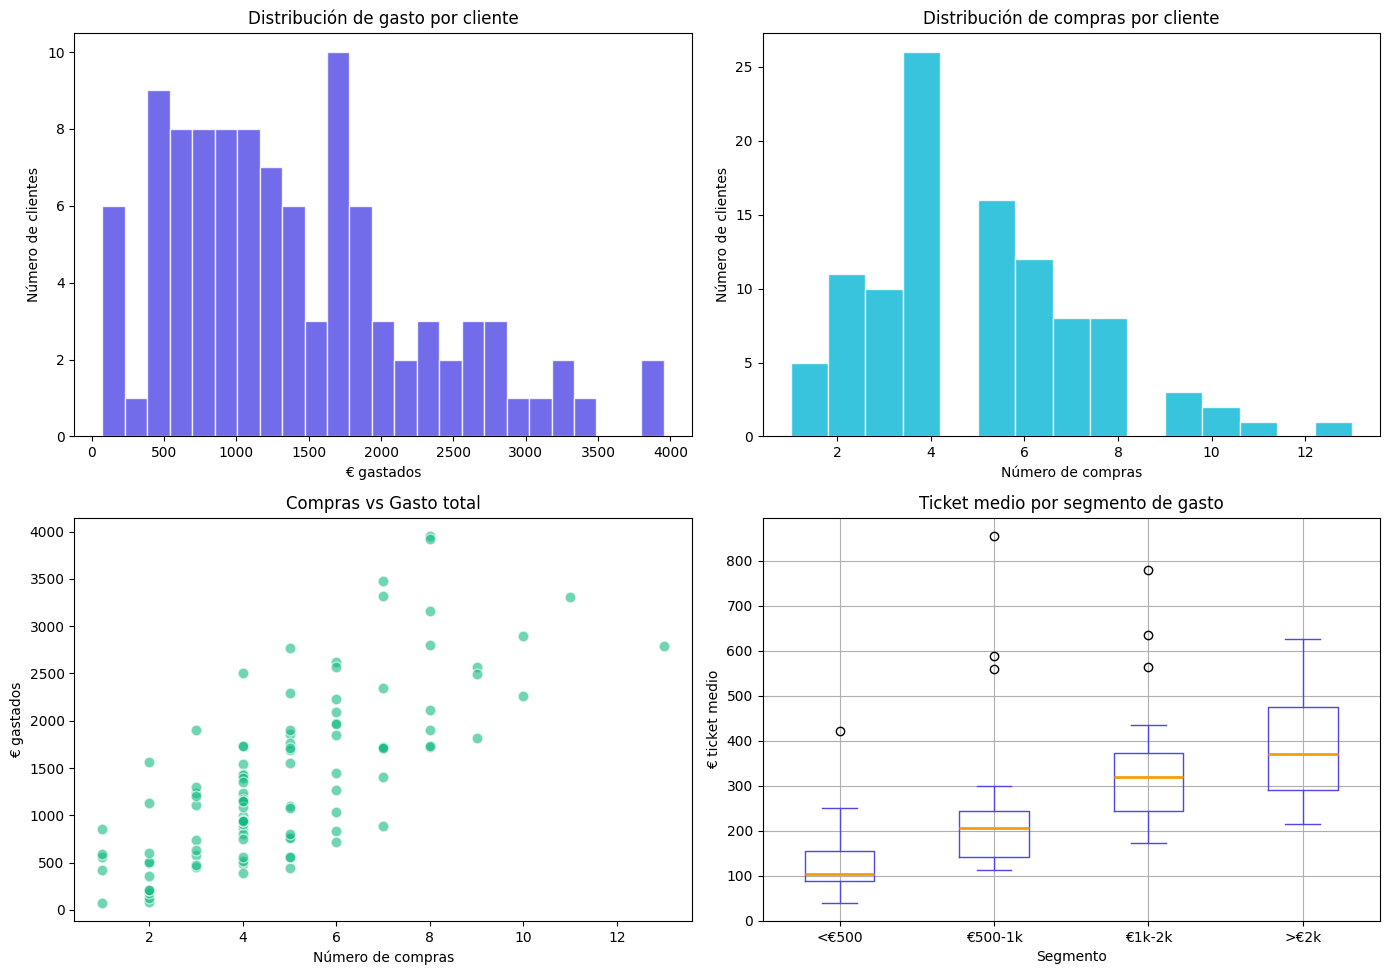

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Análisis de clientes", fontsize=14, fontweight='bold')

# Histograma: gasto total por cliente
axes[0, 0].hist(cliente_stats['total_gastado'], bins=25, color='#4f46e5', edgecolor='white', alpha=0.8)
axes[0, 0].set_title("Distribución de gasto por cliente")
axes[0, 0].set_xlabel("€ gastados")
axes[0, 0].set_ylabel("Número de clientes")

# Histograma: número de compras por cliente
axes[0, 1].hist(cliente_stats['num_compras'], bins=15, color='#06b6d4', edgecolor='white', alpha=0.8)
axes[0, 1].set_title("Distribución de compras por cliente")
axes[0, 1].set_xlabel("Número de compras")
axes[0, 1].set_ylabel("Número de clientes")

# Scatter: compras vs gasto total
axes[1, 0].scatter(
    cliente_stats['num_compras'],
    cliente_stats['total_gastado'],
    color='#10b981',
    alpha=0.6,
    edgecolors='white',
    s=60
)
axes[1, 0].set_title("Compras vs Gasto total")
axes[1, 0].set_xlabel("Número de compras")
axes[1, 0].set_ylabel("€ gastados")

# Boxplot: ticket medio por segmento
segmentos = pd.cut(
    cliente_stats['total_gastado'],
    bins=[0, 500, 1000, 2000, 5000],
    labels=['<€500', '€500-1k', '€1k-2k', '>€2k']
)
cliente_stats['segmento'] = segmentos
cliente_stats.boxplot(
    column='ticket_medio',
    by='segmento',
    ax=axes[1, 1],
    boxprops=dict(color='#4f46e5'),
    medianprops=dict(color='#f59e0b', linewidth=2),
    whiskerprops=dict(color='#4f46e5'),
    capprops=dict(color='#4f46e5'),
)
axes[1, 1].set_title("Ticket medio por segmento de gasto")
axes[1, 1].set_xlabel("Segmento")
axes[1, 1].set_ylabel("€ ticket medio")
plt.suptitle("")

plt.tight_layout()
plt.show()

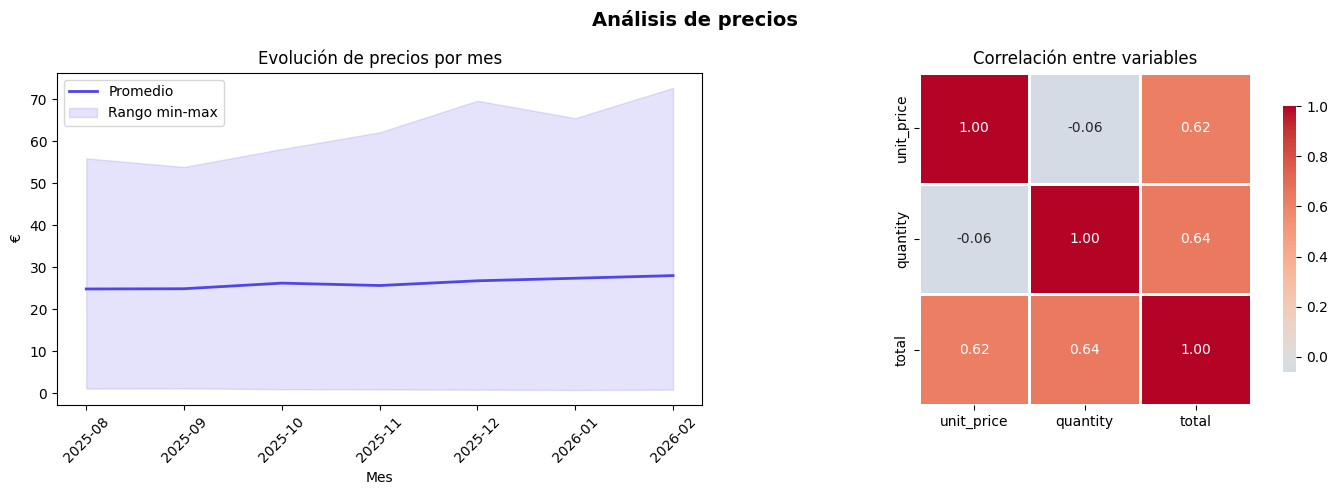

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Análisis de precios", fontsize=14, fontweight='bold')

# Evolución de precios en el tiempo
df_prices['created_at'] = pd.to_datetime(df_prices['created_at'])
precios_mes = df_prices.groupby(
    df_prices['created_at'].dt.to_period('M')
)['price'].agg(['mean', 'min', 'max']).reset_index()
precios_mes['created_at'] = precios_mes['created_at'].astype(str)

axes[0].plot(precios_mes['created_at'], precios_mes['mean'], color='#4f46e5', linewidth=2, label='Promedio')
axes[0].fill_between(
    precios_mes['created_at'],
    precios_mes['min'],
    precios_mes['max'],
    alpha=0.15,
    color='#4f46e5',
    label='Rango min-max'
)
axes[0].set_title("Evolución de precios por mes")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("€")
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Correlación entre variables numéricas
corr_matrix = df_purchases[['unit_price', 'quantity', 'total']].corr()
sns.heatmap(
    corr_matrix,
    ax=axes[1],
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8}
)
axes[1].set_title("Correlación entre variables")

plt.tight_layout()
plt.show()

In [15]:
print("═" * 55)
print("  CONCLUSIONES DEL EDA — system_admin")
print("═" * 55)

print(f"""
📦 COMPRAS
   • {len(df_purchases)} transacciones en total
   • Precio unitario promedio: €{df_purchases['unit_price'].mean():.2f}
   • Cantidad promedio por compra: {df_purchases['quantity'].mean():.1f} unidades
   • Total promedio por compra: €{df_purchases['total'].mean():.2f}
   • Compra más grande: €{df_purchases['total'].max():.2f}

🏢 EMPRESAS
   • {len(df_companies)} empresas en total
   • Top vendedor: {ventas_empresa.index[0]} (€{ventas_empresa['total_ventas'].iloc[0]:,.2f})
   • Ticket medio más alto: {ventas_empresa['ticket_medio'].idxmax()}

👥 CLIENTES
   • {len(cliente_stats)} clientes con al menos 1 compra
   • Gasto promedio por cliente: €{cliente_stats['total_gastado'].mean():,.2f}
   • Cliente más valioso: €{cliente_stats['total_gastado'].max():,.2f} gastados
   • Promedio de compras por cliente: {cliente_stats['num_compras'].mean():.1f}

💰 PRECIOS
   • {len(df_prices)} registros de precios históricos
   • Precio mínimo registrado: €{df_prices['price'].min():.2f}
   • Precio máximo registrado: €{df_prices['price'].max():.2f}
   • Precio promedio histórico: €{df_prices['price'].mean():.2f}

🔍 OBSERVACIONES
   • Alta correlación entre unit_price y total (esperada)
   • Baja correlación entre quantity y unit_price (independientes)
   • Distribución de gasto por cliente sesgada a la derecha
     → Pocos clientes gastan mucho, muchos gastan poco
   • Patrón típico para aplicar segmentación RFM
""")

═══════════════════════════════════════════════════════
  CONCLUSIONES DEL EDA — system_admin
═══════════════════════════════════════════════════════

📦 COMPRAS
   • 504 transacciones en total
   • Precio unitario promedio: €29.35
   • Cantidad promedio por compra: 10.0 unidades
   • Total promedio por compra: €287.71
   • Compra más grande: €1453.80

🏢 EMPRESAS
   • 22 empresas en total
   • Top vendedor: Talleres Pons S.Coop. (€13,405.65)
   • Ticket medio más alto: Talleres Pons S.Coop.

👥 CLIENTES
   • 103 clientes con al menos 1 compra
   • Gasto promedio por cliente: €1,407.83
   • Cliente más valioso: €3,954.17 gastados
   • Promedio de compras por cliente: 4.9

💰 PRECIOS
   • 1224 registros de precios históricos
   • Precio mínimo registrado: €0.75
   • Precio máximo registrado: €72.69
   • Precio promedio histórico: €26.49

🔍 OBSERVACIONES
   • Alta correlación entre unit_price y total (esperada)
   • Baja correlación entre quantity y unit_price (independientes)
   • Distribuc